# Dummy classifiers e árvore de decisão

In [1]:
import pandas as pd

uri = 'https://gist.githubusercontent.com/guilhermesilveira/dd7ba8142321c2c8aaa0ddd6c8862fcc/raw/e694a9b43bae4d52b6c990a5654a193c3f870750/precos.csv'

dados = pd.read_csv(uri)
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido
0,21801,2000,30941.02,1
1,7843,1998,40557.96,1
2,7109,2006,89627.50,0
3,26823,2015,95276.14,0
4,7935,2014,117384.68,1


In [2]:
dados['km_por_ano'] = dados['milhas_por_ano'] * 1.60934
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano
0,21801,2000,30941.02,1,35085.22134
1,7843,1998,40557.96,1,12622.05362
2,7109,2006,89627.50,0,11440.79806
3,26823,2015,95276.14,0,43167.32682
4,7935,2014,117384.68,1,12770.11290


In [3]:

from datetime import datetime

dados['idade'] = datetime.today().year - dados['ano_do_modelo']
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano,idade
0,21801,2000,30941.02,1,35085.22134,26
1,7843,1998,40557.96,1,12622.05362,28
2,7109,2006,89627.50,0,11440.79806,20
3,26823,2015,95276.14,0,43167.32682,11
4,7935,2014,117384.68,1,12770.11290,12


In [4]:
dados.drop(['milhas_por_ano', 'ano_do_modelo'], axis=1, inplace=True)
dados.head()

,preco,vendido,km_por_ano,idade
0,30941.02,1,35085.22134,26
1,40557.96,1,12622.05362,28
2,89627.50,0,11440.79806,20
3,95276.14,0,43167.32682,11
4,117384.68,1,12770.11290,12


In [5]:
x = dados[['preco', 'km_por_ano', 'idade']]
y = dados['vendido']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier   

seed = 23

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

classificador = DummyClassifier()
classificador.fit(raw_treino_x, treino_y)
previsoes = classificador.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia do dummy foi de {acuracia:.2f}%")

A acurácia do dummy foi de 58.00%


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier   

seed = 23

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

classificador = DummyClassifier(strategy='stratified')
classificador.fit(raw_treino_x, treino_y)
previsoes = classificador.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia do dummy foi de {acuracia:.2f}%")

A acurácia do dummy foi de 50.04%


In [8]:
len(dados.query('vendido == True')) / len(dados)

0.58

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

seed = 23

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

print(f'Tamanho do treino: {len(raw_treino_x)}')
print(f'Tamanho do teste: {len(raw_teste_x)}')

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

#modelo = LinearSVC()
modelo = SVC(gamma='auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f'A acurácia foi de {acuracia:.2f}%')

Tamanho do treino: 7500
Tamanho do teste: 2500
A acurácia foi de 76.92%


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

seed = 23

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

# print(f'Tamanho do treino: {len(raw_treino_x)}')
# print(f'Tamanho do teste: {len(raw_teste_x)}')

# scaler = StandardScaler()
# scaler.fit(raw_treino_x)

# treino_x = scaler.transform(raw_treino_x)
# teste_x = scaler.transform(raw_teste_x)

modelo = DecisionTreeClassifier(max_depth=3)
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f'A acurácia foi de {acuracia:.2f}%')

A acurácia foi de 78.36%


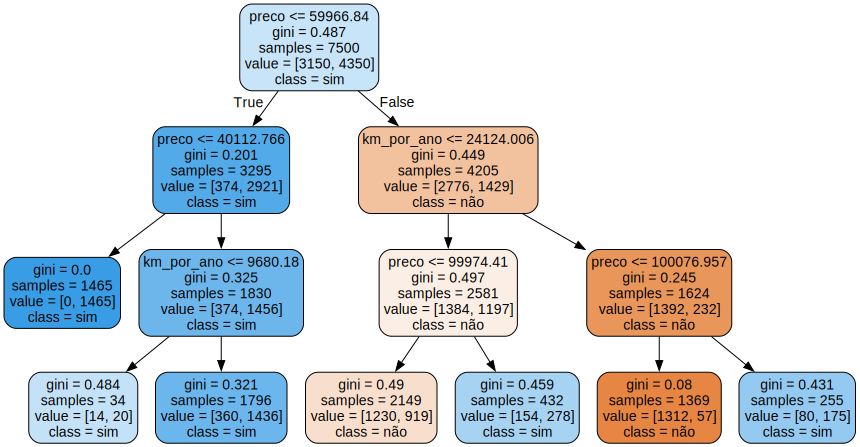

In [20]:
from sklearn.tree import export_graphviz
import graphviz

estrutura = export_graphviz(modelo, filled=True, rounded=True, feature_names=x.columns,
                            class_names=['não', 'sim'])
grafico = graphviz.Source(estrutura)
grafico